### Parameterestimering
Vi betragter en dæmpet oscillator.

$m\ddot x+b\dot x+kx=0$

Vi omskriver ligningen til to første ordens differentialligninger.

$\dot x = v$

$\dot v = -(b/m)v-(k/m)x$

Nedenfor vælger vi værdier for parametrene $m,b,k$, simulerer modellen med 30 datapunkter, lægger støj til disse på positionen, $x$.
Dernæst simuleres modellen med 100 datapunker for at kunne vise løsningen som en graf.


In [14]:
import numpy as np
from scipy.integrate import solve_ivp
m = 0.2
b = 0.1
k = 0.5
x0 = 0.0
v0 = 1.0
def f(t,y,m,b,k):
    x,v = y
    return [v,-(k/m)*x-(b/m)*v]
t = np.linspace(0,10,30)
t_plot = np.linspace(0,10,100)
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[m,b,k])
x = sol.y[0] + 0.025 * np.random.standard_normal(size = np.size(t))
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[m,b,k])

Vi plotter datapunkterne (med støj) og løsningen.
Datapunkterne ligger i nærheden af løsningen.

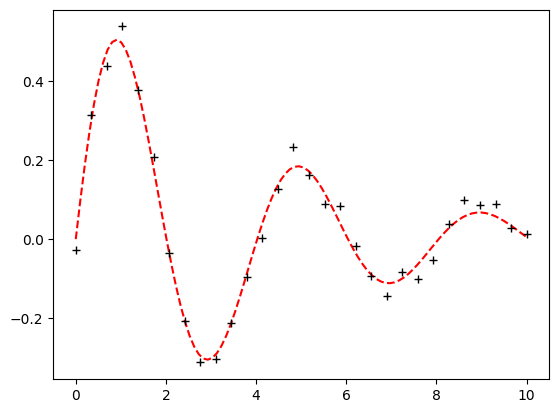

In [2]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Vi kender de oprindelige parametre, men det glemmer vi og sætter som startgæt $m=1,b=1,k=1$ og plotter dette gæt.
Der er betydelige afvigelser.

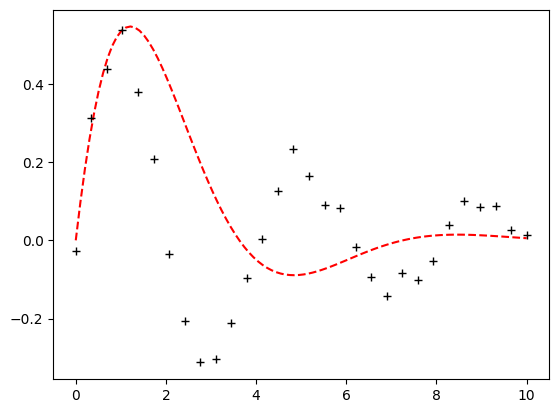

In [3]:
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[1,1,1])
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Vi laver nu et *curve_fit* som tidligere, dog har vi ikke et simpelt algebraisk udtryk for funktionen, men må løse den numerisk.
Den funktion vi laver kurvetilpasning med, *g*, beregner den numeriske løsning og returnerer udsvinget, $x$.
```python
def g(t,m,b,k):
    sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=(m,b,k))
    return sol.y[0]
```
Bemærk, at funktionen *g* udover tiden får parametrene overført, disse sendes videre til den numeriske integrator *solve_ivp*.


Dernæst kalder vi *curve_fit* der returnerer parametrene i *param* og covariansmatricen i *cov*.
Vi printer parameterværdierne og deres usikkerheder ud.

In [ ]:
from scipy.optimize import curve_fit
def g(t,m,b,k):
    sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=(m,b,k))
    return sol.y[0]
param,cov = curve_fit(g,t,x,p0=[1,1,1])
display(param)
display(np.sqrt(np.diag(cov)))

array([2.12629645, 0.99774929, 5.23534311])

array([313245.46096349, 146988.16038516, 771269.49336948])

Parameterværdierne er ikke de samme som dem vi startede med, det er lidt overraskende. 
Vi plotter den fundne løsning (parametrene er i *param*). 
Der er en fin overensstemmelse med datapunkterne, selv om parameterværdierne som sagt ikke er tæt på de oprindelige. 
Vi kan også bemærke at usikkerhederne på parametrene er gigantiske, det er også mærkeligt pga. det gode fit.

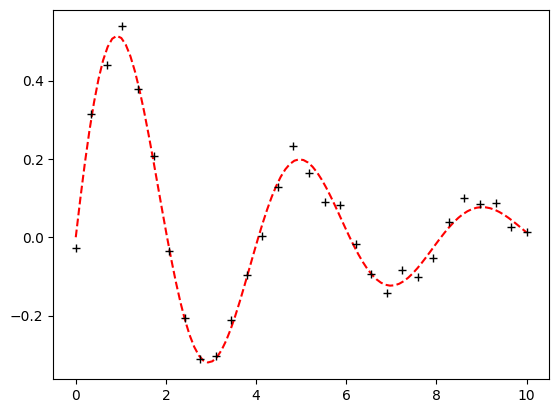

In [ ]:
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=param)
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Vi prøver nu at ændre vores startgæt til noget helt andet, vi sætter $a=1,b=2,k=0.5$.
Vi får igen andre parameterværdier og også gigatiske usikkerheder.

In [6]:
from scipy.optimize import curve_fit
def g(t,m,b,k):
    sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=(m,b,k))
    return sol.y[0]
param,cov = curve_fit(g,t,x,p0=[1,2,0.5])
display(param)
display(np.sqrt(np.diag(cov)))

array([15.08191875,  7.07708312, 37.13451468])

array([ 4675420.14879923,  2193909.80717682, 11511732.62001521])

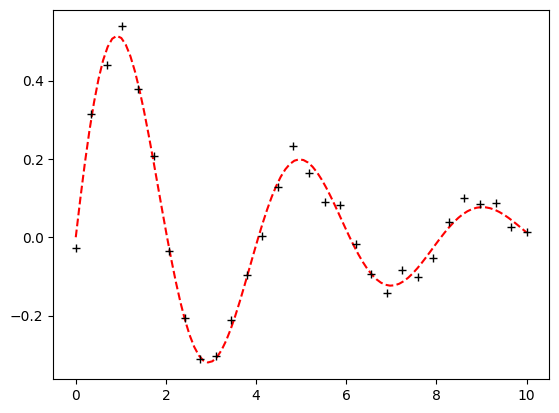

In [7]:
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=param)
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Hvis vi ser til bage på den oprindelige bevægelsesligning så kan vi se at hvis vi ganger alle parametre med en konstant så ændrer det ikke på løsningen. 
Vi omskriver nu ligningen nedefor ved at dividere igennem med $m$.
Nu passer det ikke længere at vi kan gange med en konstant og stadig få samme løsning.

$m\ddot x+b\dot x+kx=0$


Vi dividerer nu ligningen gennem med massen, $m$ og får ligningen

$\ddot x+A\dot x+Bx=0$

der kan omskriv til første ordens form.

$\dot x = v$

$\dot v = -Av-Bx$

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
m = 0.2
k = 0.5
b = 0.1
A = b/m
B = k/m
print('A={:.2f}'.format(A))
print('B={:.2f}'.format(B))
x0 = 0.0
v0 = 1.0
def f(t,y,A,B):
    x,v = y
    return [v,-B*x-A*v]
t = np.linspace(0,10,30)
t_plot = np.linspace(0,10,100)
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[A,B])
x = sol.y[0] + 0.025 * np.random.standard_normal(size = np.size(t))
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[A,B])

A=0.50
B=2.50


Vi plotter løsningen med datapunkterne med støj.

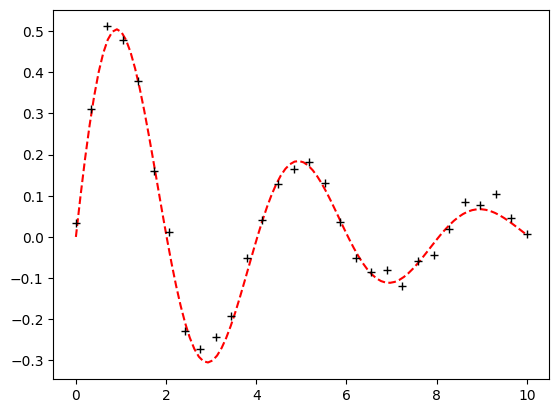

In [9]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Startgættet for parametrene er A=1 og B=1 (de rigtige værdier er A=0.5 og B=2.5).

Vi plotter startgættet.

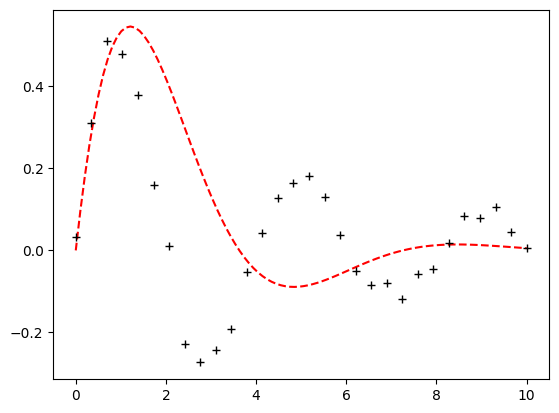

In [10]:
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[1,1])
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

Så laver vi parameterestimeringen med *curve_fit*.
Vi får parametre der denne gang ligninger de oprindelige (*A* og *B*).
Vi noterer også at vi får meget mere brugbare usikkerheder på parametrene. 

In [11]:
from scipy.optimize import curve_fit
def g(t,A,B):
    sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=(A,B))
    return sol.y[0]
param,cov = curve_fit(g,t,x,p0=[1,1])
display(param)
display(np.sqrt(np.diag(cov)))

array([0.51271949, 2.50202857])

array([0.01771367, 0.02635273])

Lad os nu plotte det endelig resultat af parameterestimeringen. Vi ser at den passer meget fint.

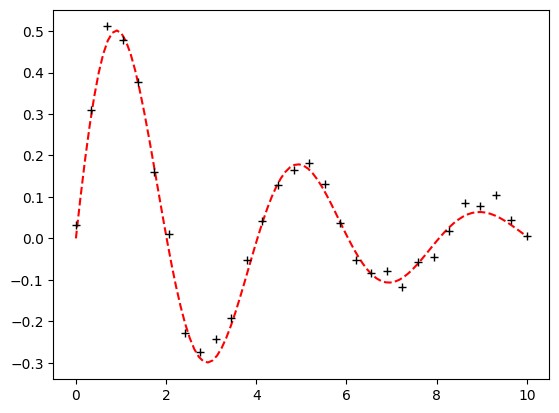

In [12]:
sol = solve_ivp(f,[t[0],t[-1]],t_eval=t_plot,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=param)
plt.figure()
plt.plot(t_plot,sol.y[0],'r--')
plt.plot(t,x,'k+')
plt.show()

For at sikre os at der kun er én løsning laver vi parameterestimering med et andet startgæt, $A=5,B=0.1$.
Vi får samme løsning (parametre og usikkerhed) som før, der ser ud til at være en unik løsning. 

In [13]:
from scipy.optimize import curve_fit
def g(t,A,B):
    sol = solve_ivp(f,[t[0],t[-1]],t_eval=t,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=(A,B))
    return sol.y[0]
param,cov = curve_fit(g,t,x,p0=[5,0.1])
display(param)
display(np.sqrt(np.diag(cov)))

array([0.51271958, 2.50202857])

array([0.01771374, 0.02635285])

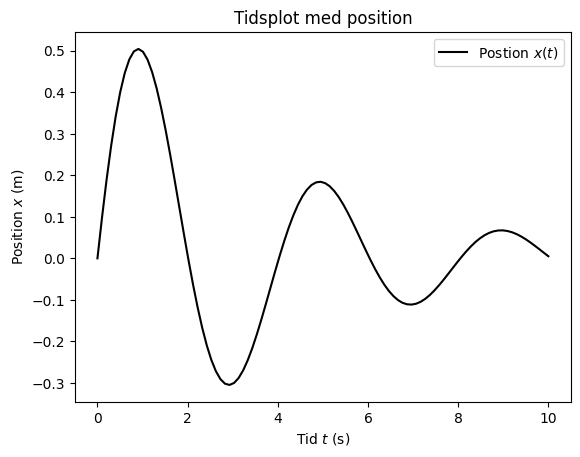

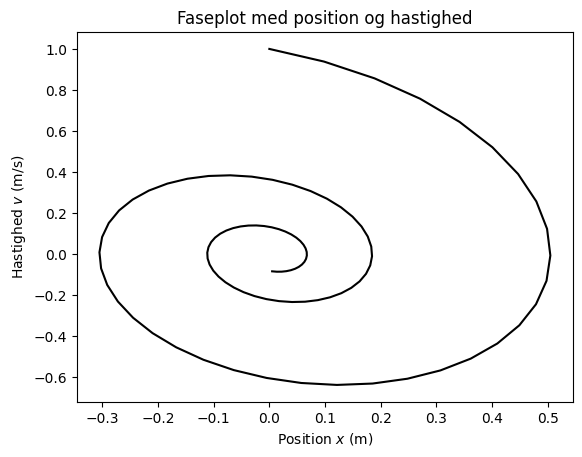

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
m = 0.2
b = 0.1
k = 0.5
x0 = 0.0
v0 = 1.0
def f(t,y,m,b,k):
    x,v = y
    return [v,-(k/m)*x-(b/m)*v]
t_eval = np.linspace(0,10,100)
sol = solve_ivp(f,[t_eval[0],t_eval[-1]],t_eval=t_eval,y0=[x0,v0],rtol=1e-8,atol=1e-8,args=[m,b,k])
import matplotlib.pyplot as plt
plt.figure()
plt.plot(sol.t,sol.y[0],'k-',label='Postion $x(t)$')
plt.title('Tidsplot med position')
plt.xlabel('Tid $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.legend()
plt.show()
plt.title('Faseplot med position og hastighed')
plt.plot(sol.y[0],sol.y[1],'k-',label='Postion $x(t)$')
plt.xlabel('Position $x$ (m)')
plt.ylabel('Hastighed $v$ (m/s)')
plt.show()

In [10]:
import numpy as np
rng = np.random.default_rng(12345678)
x = np.random.Generator.normal(rng,loc=1.0,scale=0.1,size=20)
print(x)
x = np.random.Generator.normal(rng,loc=1.0,scale=0.1,size=20)
print(x)

[0.96338784 0.83298537 0.91006129 0.8736222  0.99521082 0.94370959
 1.28980134 0.94503156 1.20218236 1.0087787  0.86465961 1.03478445
 0.91875925 0.90120851 0.99172122 0.99729694 1.09477658 0.95562638
 0.91909488 1.04124882]
[0.98678574 1.07338319 1.00701295 0.90048073 1.13182915 0.97771989
 0.99855478 0.93189325 0.83242718 0.88930356 1.1866446  0.9519026
 0.93255742 0.92508169 1.08391202 0.90536923 1.00691848 1.03823908
 0.96159917 0.8673704 ]
